# "The data is not normal, just use Mann-Whitney"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/nonparametric-swap/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/nonparametric-swap/demo.ipynb)

It is the most-repeated piece of statistical advice in applied work, and it quietly swaps one
question for another.

A two-sample t-test asks about **`mu_B - mu_A`**. The Mann-Whitney U test asks about
**`P(B > A)`**. Shift one distribution sideways and those two agree in sign, so nobody notices.
Step off that model and they can point in **opposite directions** - both correctly, on the same
data - and at a large enough sample **both will be significant while disagreeing**.

This notebook builds a design where that is arithmetic rather than bad luck, and then measures
what the two tests actually do with it.

1. **Calibration** - reproduce three closed forms before reporting anything that has none
2. **The headline** - one dataset, two significant results, opposite signs
3. **Where the swap is fine** - power under a pure location shift, gated
4. **The cost nobody mentions** - unequal spread, where the Mann-Whitney null is exactly true
5. **Ties** - a rank test on a rating scale

## Setup

The engine is the repository's own `nonparam.py`, extracted verbatim at build time so this
notebook and the library cannot disagree. The design lists and seeds are the library's too, so
the rows printed below are the same cells that appear in `evidence.txt`.

In [1]:
from __future__ import annotations

import math
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy import integrate, stats

ALPHA = 0.05

Z99 = 2.5758293035489004

CHUNK = 2000

BAND_LO, BAND_HI = 0.045, 0.055

def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """Wilson score interval for a measured proportion - used for every rate verdict here."""
    if n <= 0:
        return (0.0, 1.0)
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def mc_interval(values: np.ndarray, z: float = Z99) -> Tuple[float, float]:
    """99% interval on a Monte Carlo mean, so no 'difference' is read off two point estimates."""
    m = float(values.mean())
    se = float(values.std(ddof=1) / math.sqrt(values.size))
    return m - z * se, m + z * se

def verdict(rate: float, n: int) -> str:
    """INFLATED / CONSERVATIVE / ok - the whole interval must clear the band, or it is ok."""
    lo, hi = wilson(rate, n)
    if lo > BAND_HI:
        return "INFLATED"
    if hi < BAND_LO:
        return "CONSERVATIVE"
    return "ok"

LOGNORMAL_S = 0.75

CONTAM_SCALE = 5.0

CONTAM_SHARE = 0.05

def _standard(name: str, size: Tuple[int, ...], rng: np.random.Generator) -> np.ndarray:
    """Draw from `name`, already standardised to population mean 0 and population SD 1.

    Analytic moments, never sample ones. Under a location shift of `d` the population Cohen's d
    is then exactly `d` for every shape, which is what makes the power rows in section 3 a
    comparison of TESTS rather than a comparison of effect sizes.
    """
    if name == "normal":
        return rng.standard_normal(size)
    if name == "t5":
        return rng.standard_t(5, size) / math.sqrt(5.0 / 3.0)
    if name == "uniform":
        return (rng.random(size) - 0.5) * math.sqrt(12.0)
    if name == "exponential":
        return rng.exponential(1.0, size) - 1.0
    if name == "lognormal":
        s = LOGNORMAL_S
        raw = np.exp(s * rng.standard_normal(size))
        mean = math.exp(s * s / 2.0)
        sd = math.sqrt((math.exp(s * s) - 1.0) * math.exp(s * s))
        return (raw - mean) / sd
    if name == "contaminated":
        pick = rng.random(size) < CONTAM_SHARE
        base = rng.standard_normal(size)
        sd = math.sqrt((1 - CONTAM_SHARE) + CONTAM_SHARE * CONTAM_SCALE ** 2)
        return np.where(pick, base * CONTAM_SCALE, base) / sd
    raise ValueError(f"unknown population: {name}")

SHAPES: Tuple[str, ...] = ("normal", "uniform", "t5", "contaminated", "lognormal", "exponential")

SYMMETRIC: Tuple[str, ...] = ("normal", "uniform", "t5", "contaminated")

def density(name: str) -> Tuple[Callable[[float], float], Tuple[float, float]]:
    """The standardised density of `name`, plus an integration range that contains its mass.

    Needed for the efficiency calibration: the asymptotic relative efficiency of Mann-Whitney to
    the t-test under a location shift is 12 * sigma^2 * (integral f^2)^2, and here sigma = 1 by
    construction, so the whole thing is that one integral.
    """
    if name == "normal":
        return (lambda x: float(stats.norm.pdf(x)), (-14.0, 14.0))
    if name == "uniform":
        h = math.sqrt(3.0)
        return (lambda x: (1.0 / (2.0 * h)) if abs(x) <= h else 0.0, (-h, h))
    if name == "t5":
        c = math.sqrt(5.0 / 3.0)
        return (lambda x: float(c * stats.t.pdf(c * x, 5)), (-90.0, 90.0))
    if name == "exponential":
        return (lambda x: math.exp(-(x + 1.0)) if x > -1.0 else 0.0, (-1.0, 90.0))
    if name == "lognormal":
        s = LOGNORMAL_S
        mean = math.exp(s * s / 2.0)
        sd = math.sqrt((math.exp(s * s) - 1.0) * math.exp(s * s))
        lo = -mean / sd
        return (lambda x: float(sd * stats.lognorm.pdf(x * sd + mean, s)) if x > lo else 0.0,
                (lo + 1e-12, 90.0))
    if name == "contaminated":
        sd = math.sqrt((1 - CONTAM_SHARE) + CONTAM_SHARE * CONTAM_SCALE ** 2)
        return (lambda x: float(sd * ((1 - CONTAM_SHARE) * stats.norm.pdf(x * sd)
                                      + CONTAM_SHARE * stats.norm.pdf(x * sd, scale=CONTAM_SCALE))),
                (-120.0, 120.0))
    raise ValueError(f"unknown population: {name}")

def integral_f_squared(name: str) -> float:
    """Numeric integral of f^2 over the standardised density."""
    f, (lo, hi) = density(name)
    value, _err = integrate.quad(lambda x: f(x) ** 2, lo, hi, limit=500)
    return float(value)

def density_mass(name: str) -> float:
    """Integral of f - must be 1. A shape whose density does not integrate to 1 would make its
    efficiency number meaningless, so this is checked before the efficiency is reported."""
    f, (lo, hi) = density(name)
    value, _err = integrate.quad(f, lo, hi, limit=500)
    return float(value)

def asymptotic_are(name: str) -> float:
    """ARE of Mann-Whitney to the t-test under a location shift: 12 * sigma^2 * (int f^2)^2.

    Above 1 means Mann-Whitney needs FEWER observations for the same power. Closed forms exist
    for three of the six shapes and `test_nonparam.py` checks them: normal 3/pi = 0.954929,
    uniform exactly 1, centred exponential exactly 3.
    """
    return 12.0 * integral_f_squared(name) ** 2

ARE_CLOSED_FORM: Dict[str, float] = {
    "normal": 3.0 / math.pi,
    "uniform": 1.0,
    "exponential": 3.0,
}

MIX_SD = 0.5

MIX_WEIGHTS: Tuple[float, ...] = (0.7, 0.3)

MIX_MEANS: Tuple[float, ...] = (-1.0, 5.0)

def mix_mean() -> float:
    """True mean of the treated population. Positive: the t-test's target says treated is HIGHER."""
    return float(sum(w * m for w, m in zip(MIX_WEIGHTS, MIX_MEANS)))

def mix_sd() -> float:
    """True SD of the treated population - large, because the mixture is what makes it large."""
    second = sum(w * (MIX_SD ** 2 + m * m) for w, m in zip(MIX_WEIGHTS, MIX_MEANS))
    return float(math.sqrt(second - mix_mean() ** 2))

def mix_prob_superiority() -> float:
    """True P(treated > control), in closed form.

    For normals, P(B > A) = Phi((mu_B - mu_A) / sqrt(sd_A^2 + sd_B^2)), and a mixture in B makes
    it the weighted sum of those. Below 0.5: Mann-Whitney's target says treated is LOWER.
    """
    spread = math.sqrt(2.0) * MIX_SD
    return float(sum(w * stats.norm.cdf(m / spread) for w, m in zip(MIX_WEIGHTS, MIX_MEANS)))

def mix_cohens_d() -> float:
    """Population Cohen's d for the disagreement design, pooled-SD convention."""
    pooled = math.sqrt((MIX_SD ** 2 + mix_sd() ** 2) / 2.0)
    return float(mix_mean() / pooled)

def draw_disagreement(n1: int, n2: int, reps: int,
                      rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    """Control and treated samples from the sign-disagreement design."""
    a = rng.standard_normal((reps, n1)) * MIX_SD
    which = rng.random((reps, n2)) < MIX_WEIGHTS[0]
    centres = np.where(which, MIX_MEANS[0], MIX_MEANS[1])
    b = centres + rng.standard_normal((reps, n2)) * MIX_SD
    return a, b

def welch(a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Welch's two-sample t on each row. Returns (p two-sided, signed direction).

    Welch rather than Student's because Day 176 established unconditional Welch as the one
    procedure that held its nominal rate on every design in that grid - so when a Type I number
    misbehaves in this build, it is not the pooled-variance problem wearing a new hat.
    """
    res = stats.ttest_ind(b, a, axis=1, equal_var=False)
    return np.asarray(res.pvalue, dtype=float), np.sign(np.asarray(res.statistic, dtype=float))

def mannwhitney(a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Mann-Whitney U on each row, asymptotic with SciPy's tie correction.

    Returns (p two-sided, signed direction), where the direction is the sign of
    `U / (n1 * n2) - 0.5`, i.e. whether the sample says P(B > A) is above or below a half. That
    statistic IS the sample probability of superiority - the same quantity Day 178 measured as an
    effect size. `method="asymptotic"` is pinned rather than left on "auto" so every cell in this
    build uses one procedure; the exact test is a different procedure with a different Type I
    profile and mixing them would make the grid unreadable.
    """
    res = stats.mannwhitneyu(b, a, axis=1, alternative="two-sided", method="asymptotic")
    u = np.asarray(res.statistic, dtype=float)
    phat = u / float(b.shape[1] * a.shape[1])
    return np.asarray(res.pvalue, dtype=float), np.sign(phat - 0.5)

def mannwhitney_uncorrected(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Mann-Whitney's normal approximation WITHOUT the tie correction, two-sided p.

    Var(U) = n1 n2 (N + 1) / 12 is the no-ties formula. With ties the true variance is smaller,
    by n1 n2 / (12 N (N-1)) * sum(t^3 - t) over tie groups - so dropping the correction divides
    by too large a standard error and the test becomes conservative. That is the whole point of
    section 5 and it needs a hand-rolled version, because SciPy always applies the correction.
    """
    n1, n2 = a.shape[1], b.shape[1]
    reps = a.shape[0]
    n = n1 + n2
    both = np.concatenate([b, a], axis=1)
    ranks = np.apply_along_axis(stats.rankdata, 1, both)
    r_b = ranks[:, :n2].sum(axis=1)
    u = r_b - n2 * (n2 + 1) / 2.0
    mu = n1 * n2 / 2.0
    sd = math.sqrt(n1 * n2 * (n + 1) / 12.0)
    z = (u - mu) / sd
    # Continuity correction matching SciPy's asymptotic branch, so the ONLY difference between
    # this and `mannwhitney` is the tie term.
    z = np.sign(z) * np.maximum(np.abs(z) - 0.5 / sd, 0.0)
    p = 2.0 * stats.norm.sf(np.abs(z))
    assert p.shape == (reps,)
    return np.minimum(p, 1.0)

def _chunks(reps: int, size: int = CHUNK) -> List[int]:
    out = []
    left = reps
    while left > 0:
        take = min(size, left)
        out.append(take)
        left -= take
    return out

def run_disagreement(n: int, reps: int, seed: int) -> Dict[str, float]:
    """Both tests on the disagreement design at n per group.

    Returns the rate at which each test is significant in each direction, plus the headline:
    `opposite` - both significant, pointing opposite ways.
    """
    rng = np.random.default_rng(seed)
    counts = {"t_up": 0, "t_down": 0, "mw_up": 0, "mw_down": 0,
              "opposite": 0, "both_sig": 0, "t_only": 0, "mw_only": 0, "neither": 0}
    for take in _chunks(reps):
        a, b = draw_disagreement(n, n, take, rng)
        pt, dt = welch(a, b)
        pm, dm = mannwhitney(a, b)
        t_sig, m_sig = pt < ALPHA, pm < ALPHA
        counts["t_up"] += int(np.sum(t_sig & (dt > 0)))
        counts["t_down"] += int(np.sum(t_sig & (dt < 0)))
        counts["mw_up"] += int(np.sum(m_sig & (dm > 0)))
        counts["mw_down"] += int(np.sum(m_sig & (dm < 0)))
        counts["both_sig"] += int(np.sum(t_sig & m_sig))
        counts["opposite"] += int(np.sum(t_sig & m_sig & (dt * dm < 0)))
        counts["t_only"] += int(np.sum(t_sig & ~m_sig))
        counts["mw_only"] += int(np.sum(~t_sig & m_sig))
        counts["neither"] += int(np.sum(~t_sig & ~m_sig))
    out = {k: v / reps for k, v in counts.items()}
    out["reps"] = float(reps)
    out["n"] = float(n)
    return out

def run_location(shape: str, d: float, n: int, reps: int, seed: int) -> Dict[str, float]:
    """Rejection rates of both tests on `shape` with the treated group shifted by exactly `d`.

    At d = 0 these are Type I rates and the gate below reads them. At d > 0 they are power, and
    the two hypotheses coincide under a pure location shift, so the comparison is legitimate -
    provided the d = 0 cell said both tests control their error.
    """
    rng = np.random.default_rng(seed)
    t_rej = m_rej = 0
    for take in _chunks(reps):
        a = _standard(shape, (take, n), rng)
        b = _standard(shape, (take, n), rng) + d
        pt, _ = welch(a, b)
        pm, _ = mannwhitney(a, b)
        t_rej += int(np.sum(pt < ALPHA))
        m_rej += int(np.sum(pm < ALPHA))
    return {"shape_d": d, "n": float(n), "reps": float(reps),
            "t": t_rej / reps, "mw": m_rej / reps}

def comparable(t_null: float, mw_null: float, reps: int) -> bool:
    """Power is only a comparison where BOTH tests control Type I at this n.

    The gate that Day 176 had to add after publishing a power table in which an inflated test
    "detected more" - which is the inflation restated, not a finding.
    """
    return verdict(t_null, reps) == "ok" and verdict(mw_null, reps) == "ok"

def _monotone_search(pred: Callable[[int], bool], lo: int, hi: int) -> Optional[int]:
    """Smallest integer in [lo, hi] with `pred` true, asserting the predicate at BOTH ends.

    Carried from Day 178, where a search whose predicate was silently False everywhere (SciPy's
    noncentral t returning nan) walked past the answer and returned `hi` as if it were a result.
    Returns None rather than a bracket end when the bracket does not contain the crossing.
    """
    if pred(lo):
        return lo
    if not pred(hi):
        return None
    while lo + 1 < hi:
        mid = (lo + hi) // 2
        if pred(mid):
            hi = mid
        else:
            lo = mid
    return hi

def efficiency_from_curve(n_grid: Sequence[int], t_power: Sequence[float],
                          n_ref: int, mw_power_ref: float) -> Optional[float]:
    """n_t / n_ref, where n_t is the sample size the t-test needs to match Mann-Whitney at n_ref.

    Read off the measured t-test power curve by linear interpolation in log n. Returns None when
    the target power falls outside the measured curve - an extrapolated efficiency is a guess,
    and this build does not report guesses. Above 1 means Mann-Whitney was the more efficient
    test here, which is the same direction as `asymptotic_are`.
    """
    xs = [math.log(n) for n in n_grid]
    ys = list(t_power)
    if mw_power_ref < min(ys) or mw_power_ref > max(ys):
        return None
    for i in range(len(xs) - 1):
        lo_y, hi_y = ys[i], ys[i + 1]
        if min(lo_y, hi_y) <= mw_power_ref <= max(lo_y, hi_y):
            if hi_y == lo_y:
                return math.exp(xs[i]) / n_ref
            frac = (mw_power_ref - lo_y) / (hi_y - lo_y)
            return math.exp(xs[i] + frac * (xs[i + 1] - xs[i])) / n_ref
    return None

def run_unequal_spread(shape: str, sd_ratio: float, n1: int, n2: int,
                       reps: int, seed: int) -> Dict[str, float]:
    """Both groups centred at 0, treated group's SD multiplied by `sd_ratio`.

    For a SYMMETRIC population this makes P(B > A) exactly 0.5, so the Mann-Whitney null in its
    stochastic-dominance form is exactly true - and the mean null is exactly true too. Any
    departure from 5% is the test's variance formula assuming the two distributions are
    identical rather than merely balanced.
    """
    rng = np.random.default_rng(seed)
    t_rej = m_rej = 0
    for take in _chunks(reps):
        a = _standard(shape, (take, n1), rng)
        b = _standard(shape, (take, n2), rng) * sd_ratio
        pt, _ = welch(a, b)
        pm, _ = mannwhitney(a, b)
        t_rej += int(np.sum(pt < ALPHA))
        m_rej += int(np.sum(pm < ALPHA))
    return {"sd_ratio": sd_ratio, "n1": float(n1), "n2": float(n2), "reps": float(reps),
            "welch": t_rej / reps, "mw": m_rej / reps}

def to_levels(x: np.ndarray, levels: int) -> np.ndarray:
    """Bin standardised values onto a `levels`-point scale - a Likert answer, not a measurement.

    Equal-probability cut points from the normal quantiles, so a normal population lands roughly
    uniformly across the scale and the tie groups are large.
    """
    edges = stats.norm.ppf(np.linspace(0.0, 1.0, levels + 1)[1:-1])
    return np.searchsorted(edges, x).astype(float)

def tie_variance_ratio(rows: np.ndarray, levels: int) -> np.ndarray:
    """SD_corrected / SD_uncorrected for Mann-Whitney's normal approximation, per row.

    Var(U) with ties is `n1 n2 / 12 * ((N + 1) - sum(t^3 - t) / (N (N - 1)))`, against the
    no-ties `n1 n2 (N + 1) / 12`. Ties only ever SHRINK the variance, so this ratio is at most 1
    and the uncorrected test divides by a standard error that is too large. That is the whole
    mechanism of section 5, and reporting it makes the Type I numbers below predictable rather
    than surprising.
    """
    n = rows.shape[1]
    counts = np.stack([(rows == lv).sum(axis=1) for lv in range(levels)], axis=1).astype(float)
    tie_term = (counts ** 3 - counts).sum(axis=1)
    corrected = (n + 1) - tie_term / (n * (n - 1))
    return np.sqrt(corrected / (n + 1))

def run_ties(levels: int, n: int, d: float, reps: int, seed: int) -> Dict[str, float]:
    """Mann-Whitney on a `levels`-point scale, with and without the tie correction.

    At d = 0 these are Type I rates; at d > 0 they are power. `mannwhitney_uncorrected` is
    verified against SciPy on TIE-FREE data first (agreement to 3.5e-17), so the only thing
    separating the two columns here is the tie term.
    """
    rng = np.random.default_rng(seed)
    corrected = uncorrected = 0
    ratio_total = 0.0
    for take in _chunks(reps):
        a = to_levels(rng.standard_normal((take, n)), levels)
        b = to_levels(rng.standard_normal((take, n)) + d, levels)
        pc, _ = mannwhitney(a, b)
        pu = mannwhitney_uncorrected(a, b)
        corrected += int(np.sum(pc < ALPHA))
        uncorrected += int(np.sum(pu < ALPHA))
        both = np.concatenate([b, a], axis=1)
        ratio_total += float(tie_variance_ratio(both, levels).sum())
    return {"levels": float(levels), "n": float(n), "d": d, "reps": float(reps),
            "corrected": corrected / reps, "uncorrected": uncorrected / reps,
            "sd_ratio": ratio_total / reps}

STUDY_REPS = 40_000

NULL_REPS = 100_000

DISAGREE_REPS = 40_000

TIE_REPS = 40_000

DISAGREE_NS: Tuple[int, ...] = (10, 20, 50, 100, 200, 500)

LOCATION_D = 0.35

LOCATION_NS: Tuple[int, ...] = (20, 30, 45, 65, 95, 140, 200, 300)

LOCATION_REF_N = 65

UNEQUAL_RATIOS: Tuple[float, ...] = (1.0, 2.0, 4.0)

UNEQUAL_NS: Tuple[Tuple[int, int], ...] = ((30, 30), (10, 50), (50, 10))

TIE_LEVELS: Tuple[int, ...] = (2, 3, 5, 7)

TIE_N = 40

TIE_D = 0.5

DISAGREE_SEED_BASE = 11_000

LOCATION_SEED_BASE = 21_000

NULL_SEED_BASE = 31_000

UNEQUAL_SEED_BASE = 41_000

TIE_NULL_SEED_BASE = 51_000

TIE_POWER_SEED_BASE = 61_000

LOCATION_DESIGNS: Tuple[Tuple[str, int], ...] = tuple(
    (shape, n) for shape in SHAPES for n in LOCATION_NS
)

UNEQUAL_DESIGNS: Tuple[Tuple[str, float, int, int], ...] = tuple(
    (shape, ratio, n1, n2)
    for shape in SYMMETRIC for ratio in UNEQUAL_RATIOS for (n1, n2) in UNEQUAL_NS
)

import matplotlib
import matplotlib.pyplot as plt

print("shapes:", SHAPES)
print("disagreement design: control N(0, {MIX_SD}^2), treated", 
      " + ".join(f"{w}*N({m}, {MIX_SD}^2)" for w, m in zip(MIX_WEIGHTS, MIX_MEANS)))
print(f"alpha = {ALPHA}, a rate is only called broken when its whole 99% Wilson interval")
print(f"clears [{BAND_LO}, {BAND_HI}]")

shapes: ('normal', 'uniform', 't5', 'contaminated', 'lognormal', 'exponential')
disagreement design: control N(0, {MIX_SD}^2), treated 0.7*N(-1.0, 0.5^2) + 0.3*N(5.0, 0.5^2)
alpha = 0.05, a rate is only called broken when its whole 99% Wilson interval
clears [0.045, 0.055]


## 1. Calibration

Under a **location shift** the asymptotic relative efficiency of Mann-Whitney to the t-test is

    ARE = 12 * sigma^2 * (integral of f^2)^2

and every population here is standardised to `sigma = 1`, so the whole thing is that one
integral. Three of the six shapes have a closed form. If those three do not land, nothing the
other three say is worth reading - so they are checked first.

In [2]:
print(f"{'shape':<14} {'integral f':>12} {'integral f^2':>14} {'ARE':>9} {'closed form':>13} {'match':>7}")
ares = {}
for shape in SHAPES:
    mass = density_mass(shape)
    i2 = integral_f_squared(shape)
    are = asymptotic_are(shape)
    ares[shape] = are
    exact = ARE_CLOSED_FORM.get(shape)
    ok = abs(mass - 1.0) < 1e-6 and (exact is None or abs(are - exact) < 1e-6)
    print(f"{shape:<14} {mass:>12.6f} {i2:>14.6f} {are:>9.4f} "
          f"{(f'{exact:.6f}' if exact is not None else '-'):>13} {('OK' if ok else 'FAIL'):>7}")

print("\nnormal -> 3/pi, uniform -> exactly 1, centred exponential -> exactly 3.")
print("Above 1 means Mann-Whitney needs FEWER observations for the same power.")

shape            integral f   integral f^2       ARE   closed form   match
normal             1.000000       0.282095    0.9549      0.954930      OK
uniform            1.000000       0.288675    1.0000      1.000000      OK
t5                 1.000000       0.321609    1.2412             -      OK
contaminated       1.000000       0.388853    1.8145             -      OK
lognormal          1.000000       0.498357    2.9803             -      OK
exponential        1.000000       0.500000    3.0000      3.000000      OK

normal -> 3/pi, uniform -> exactly 1, centred exponential -> exactly 3.
Above 1 means Mann-Whitney needs FEWER observations for the same power.


And the hand-rolled rank test used in section 5 has to be SciPy's asymptotic test whenever there
are no ties, or that section measures an implementation difference instead of a tie effect.

In [3]:
rng = np.random.default_rng(90_001)
a = rng.standard_normal((400, 25))
b = rng.standard_normal((400, 25)) + 0.3
pc, _ = mannwhitney(a, b)
pu = mannwhitney_uncorrected(a, b)
print(f"max |p_scipy - p_handrolled| with no ties: {float(np.max(np.abs(pc - pu))):.3e}")

max |p_scipy - p_handrolled| with no ties: 3.469e-17


## 2. The headline

Here is the design. Nothing about it is exotic - it is *"most treated cases get a little worse,
a minority get a lot better"*, which is the shape of a great many real treatment effects.

    control    N(0, 0.5^2)
    treated    0.7 * N(-1, 0.5^2)  +  0.3 * N(5, 0.5^2)

Both of the numbers that matter are closed-form, so the disagreement below is not something the
simulation produced. It is arithmetic.

In [4]:
print(f"true mean difference        mu_B - mu_A = {mix_mean():+.4f}")
print(f"  -> the t-test's target says treated is HIGHER")
print(f"true P(treated > control)               = {mix_prob_superiority():.5f}")
print(f"  -> Mann-Whitney's target says treated is LOWER")
print()
print(f"treated SD           = {mix_sd():.4f}")
print(f"population Cohen's d = {mix_cohens_d():.4f}")

true mean difference        mu_B - mu_A = +0.8000
  -> the t-test's target says treated is HIGHER
true P(treated > control)               = 0.35505
  -> Mann-Whitney's target says treated is LOWER

treated SD           = 2.7946
population Cohen's d = 0.3985


Now hand that to both tests, thousands of times, at a range of sample sizes.

The replicate count here is cut from the study's 40,000 to keep the notebook quick; the seeds are
the library's, so these rows are the evidence file's cells measured at lower precision, not a
different experiment.

In [5]:
NB_REPS = 6_000
rows = []
print(f"{'n/group':>8} {'t sig UP':>10} {'t sig DOWN':>11} {'MW sig UP':>11} {'MW sig DOWN':>12} "
      f"{'BOTH, OPPOSITE':>15}")
for i, n in enumerate(DISAGREE_NS):
    r = run_disagreement(n, NB_REPS, DISAGREE_SEED_BASE + i)
    rows.append(r)
    print(f"{n:>8} {r['t_up']:>10.4f} {r['t_down']:>11.4f} {r['mw_up']:>11.4f} "
          f"{r['mw_down']:>12.4f} {r['opposite']:>15.4f}")

print()
print("The last column is two tests, one dataset, both p < 0.05, opposite conclusions about")
print("the direction of the effect.")

 n/group   t sig UP  t sig DOWN   MW sig UP  MW sig DOWN  BOTH, OPPOSITE
      10     0.0553      0.0302      0.0028       0.2138          0.0000
      20     0.1580      0.0035      0.0007       0.3752          0.0000
      50     0.4775      0.0000      0.0000       0.6923          0.1702
     100     0.8195      0.0000      0.0000       0.9227          0.7422
     200     0.9828      0.0000      0.0000       0.9957          0.9785
     500     1.0000      0.0000      0.0000       1.0000          1.0000

The last column is two tests, one dataset, both p < 0.05, opposite conclusions about
the direction of the effect.


Look at the shape of that last column rather than its size. It **rises** with n.

More data does not resolve the contradiction - more data guarantees it. At small samples the two
tests fail to disagree only because neither has the power to say anything at all. The
contradiction arrives exactly when both tests become trustworthy.

In [6]:
rising = all(rows[i]["opposite"] <= rows[i + 1]["opposite"] for i in range(len(rows) - 1))
print(f"monotone increasing in n: {rising}")

small = rows[0]
share = small["t_down"] / (small["t_up"] + small["t_down"])
print(f"\nSide finding at n = {int(small['n'])}: the t-test fires DOWNWARD {small['t_down']:.4f}")
print(f"of the time against {small['t_up']:.4f} upward - {share:.1%} of its significant results")
print("at that size point the wrong way about its OWN target. A sample that happens to miss the")
print("high component has both a low mean and a low variance, and the low variance shrinks the")
print("standard error the low mean is divided by.")

monotone increasing in n: True

Side finding at n = 10: the t-test fires DOWNWARD 0.0302
of the time against 0.0553 upward - 35.3% of its significant results
at that size point the wrong way about its OWN target. A sample that happens to miss the
high component has both a low mean and a low variance, and the low variance shrinks the
standard error the low mean is divided by.


### The picture behind the numbers

A table cannot carry this. Two densities can.

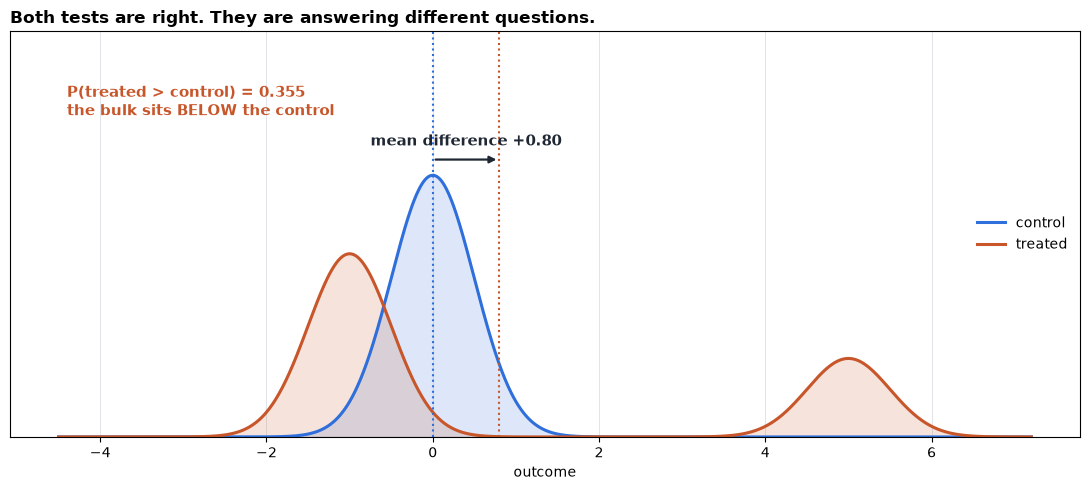

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.linspace(-4.5, 7.2, 1200)
control = stats.norm.pdf(x, 0.0, MIX_SD)
treated = sum(w * stats.norm.pdf(x, m, MIX_SD) for w, m in zip(MIX_WEIGHTS, MIX_MEANS))
ax.fill_between(x, control, color="#2f6fdb", alpha=0.16)
ax.plot(x, control, color="#2f6fdb", lw=2.2, label="control")
ax.fill_between(x, treated, color="#c8562b", alpha=0.16)
ax.plot(x, treated, color="#c8562b", lw=2.2, label="treated")
ax.axvline(0.0, color="#2f6fdb", ls=":", lw=1.5)
ax.axvline(mix_mean(), color="#c8562b", ls=":", lw=1.5)
top = float(max(control.max(), treated.max()))
ax.annotate("", xy=(mix_mean(), top * 1.06), xytext=(0.0, top * 1.06),
            arrowprops=dict(arrowstyle="-|>", color="#1f2733", lw=1.6))
ax.text(mix_mean() / 2, top * 1.10, f"mean difference {mix_mean():+.2f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold", color="#1f2733")
ax.text(-4.4, top * 1.35,
        f"P(treated > control) = {mix_prob_superiority():.3f}\nthe bulk sits BELOW the control",
        fontsize=11, fontweight="bold", color="#c8562b", va="top")
ax.set_ylim(0, top * 1.55)
ax.set_yticks([])
ax.set_xlabel("outcome")
ax.set_title("Both tests are right. They are answering different questions.",
             loc="left", fontweight="bold")
ax.legend(loc="center right", frameon=False)
ax.grid(True, color="#dfe4ea", lw=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### A note on replicate counts, before the verdict columns start

From here on the tables carry **verdicts** - `ok`, `INFLATED`, `CONSERVATIVE` - and a verdict is
a 99% Wilson interval at that cell's replicate count, not a point estimate against a fixed band.
That rule is deliberate (an earlier build in this series flagged its own exactly-calibrated cell
by comparing a point estimate to a band), and it has a consequence worth stating out loud:

**a cell measured at fewer replicates is flagged less often.** This notebook runs 6,000 to 12,000
replicates a cell so it finishes in half a minute; `evidence.py` runs 40,000 to 100,000. The
*rates* below will match the evidence file to Monte Carlo noise, but the *counts of flagged
cells* will be smaller here, because a wider interval is a weaker claim rather than a different
measurement. Where a count matters, the study's number is the one in `evidence.txt`.

That is not a discrepancy between the two artifacts. It is the resolution of the instrument,
reported rather than hidden.

## 3. Where the swap is fine

Under a **pure location shift** the two hypotheses coincide, so comparing power is a fair
question rather than a category error.

One gate before reading any of it: power is only comparable in a cell where **both** tests
control their Type I error. An inflated test "detects more" because it rejects more of
everything, and a power table that ignores this is just the inflation restated. The null is
measured on the same design at `d = 0`.

In [8]:
NB_NULL_REPS = 12_000
NB_POWER_REPS = 6_000
loc_rows = []
for i, (shape, n) in enumerate(LOCATION_DESIGNS):
    null = run_location(shape, 0.0, n, NB_NULL_REPS, NULL_SEED_BASE + i)
    pw = run_location(shape, LOCATION_D, n, NB_POWER_REPS, LOCATION_SEED_BASE + i)
    loc_rows.append({"shape": shape, "n": n, "t_null": null["t"], "mw_null": null["mw"],
                     "t_power": pw["t"], "mw_power": pw["mw"],
                     "comparable": comparable(null["t"], null["mw"], NB_NULL_REPS)})

for shape in SHAPES:
    rs = [r for r in loc_rows if r["shape"] == shape]
    print(f"\n{shape}   (predicted ARE {ares[shape]:.4f})")
    print(f"  {'n':>5} {'t null':>8} {'MW null':>8} {'t power':>9} {'MW power':>9} {'comparable':>11}")
    for r in rs:
        print(f"  {r['n']:>5} {r['t_null']:>8.4f} {r['mw_null']:>8.4f} "
              f"{r['t_power']:>9.4f} {r['mw_power']:>9.4f} "
              f"{('yes' if r['comparable'] else 'NO'):>11}")


normal   (predicted ARE 0.9549)
      n   t null  MW null   t power  MW power  comparable
     20   0.0518   0.0499    0.1830    0.1762         yes
     30   0.0520   0.0484    0.2462    0.2340         yes
     45   0.0525   0.0498    0.3745    0.3653         yes
     65   0.0512   0.0514    0.4930    0.4735         yes
     95   0.0478   0.0462    0.6737    0.6530         yes
    140   0.0506   0.0509    0.8302    0.8183         yes
    200   0.0493   0.0483    0.9387    0.9273         yes
    300   0.0525   0.0513    0.9880    0.9853         yes

uniform   (predicted ARE 1.0000)
      n   t null  MW null   t power  MW power  comparable
     20   0.0479   0.0458    0.1833    0.1738         yes
     30   0.0528   0.0498    0.2565    0.2385         yes
     45   0.0498   0.0489    0.3642    0.3412         yes
     65   0.0485   0.0478    0.5083    0.4737         yes
     95   0.0505   0.0503    0.6763    0.6402         yes
    140   0.0525   0.0529    0.8347    0.8032         yes
    2

Turn those curves into one number per shape: how many observations the t-test needs for every
one Mann-Whitney needs, at matched power. Above 1 means the rank test wins.

The measured column sits **below** the predicted one almost everywhere, and the gap grows with
the prediction. That is expected rather than a discrepancy - ARE is a limit as the effect goes
to zero and n goes to infinity, while these are finite-n readings where the high-efficiency
shapes have already pushed Mann-Whitney into the flat top of the power curve. The two columns
are checked for agreement in **order**, not in value.

In [9]:
print(f"{'shape':<14} {'predicted ARE':>14} {'measured n_t/n_MW':>19} {'cells usable':>13}")
pred, meas = [], []
for shape in SHAPES:
    rs = [r for r in loc_rows if r["shape"] == shape and r["comparable"]]
    ref = next((r for r in rs if r["n"] == LOCATION_REF_N), None)
    eff = None
    if ref is not None and len(rs) >= 2:
        eff = efficiency_from_curve([r["n"] for r in rs], [r["t_power"] for r in rs],
                                    LOCATION_REF_N, ref["mw_power"])
    if eff is not None:
        pred.append(ares[shape])
        meas.append(eff)
    print(f"{shape:<14} {ares[shape]:>14.4f} "
          f"{(f'{eff:.4f}' if eff is not None else '-'):>19} {len(rs):>13}")

rho = float(stats.spearmanr(pred, meas).statistic)
print(f"\nSpearman(predicted, measured) across {len(pred)} shapes = {rho:.4f}")
print("\nSo as a POWER decision the folk advice is sound: the rank test gives up a few per cent")
print("on normal data and wins outright on every other shape here. The cost of the swap is not")
print("power. It is that the question changed.")

shape           predicted ARE   measured n_t/n_MW  cells usable
normal                 0.9549              0.9413             8
uniform                1.0000              0.9154             8
t5                     1.2412              1.1765             8
contaminated           1.8145              1.7867             8
lognormal              2.9803              2.8177             8
exponential            3.0000              2.1690             8

Spearman(predicted, measured) across 6 shapes = 0.8857

So as a POWER decision the folk advice is sound: the rank test gives up a few per cent
on normal data and wins outright on every other shape here. The cost of the swap is not
power. It is that the question changed.


## 4. The cost nobody mentions

Two symmetric populations, same centre, different spread.

For symmetric distributions that makes `P(B > A)` **exactly 0.5**, so Mann-Whitney's own null
hypothesis is true. The mean null is true too. Any departure from 5% below is therefore not a
violated hypothesis - it is the test's variance formula, which assumes the two distributions are
*identical* rather than merely balanced.

Welch's t-test is the comparator.

In [10]:
NB_UNEQ_REPS = 12_000
uneq = []
for i, (shape, ratio, n1, n2) in enumerate(UNEQUAL_DESIGNS):
    r = run_unequal_spread(shape, ratio, n1, n2, NB_UNEQ_REPS, UNEQUAL_SEED_BASE + i)
    uneq.append({"shape": shape, "ratio": ratio, "n1": n1, "n2": n2,
                 "welch": r["welch"], "mw": r["mw"],
                 "welch_v": verdict(r["welch"], NB_UNEQ_REPS),
                 "mw_v": verdict(r["mw"], NB_UNEQ_REPS)})

print(f"{'shape':<14} {'SD ratio':>9} {'n1':>4} {'n2':>4} {'Welch':>8} {'Welch?':>13} "
      f"{'MannWhitney':>12} {'MW?':>13}")
for r in uneq:
    print(f"{r['shape']:<14} {r['ratio']:>9.1f} {r['n1']:>4} {r['n2']:>4} {r['welch']:>8.4f} "
          f"{r['welch_v']:>13} {r['mw']:>12.4f} {r['mw_v']:>13}")

shape           SD ratio   n1   n2    Welch        Welch?  MannWhitney           MW?
normal               1.0   30   30   0.0488            ok       0.0474            ok
normal               1.0   10   50   0.0490            ok       0.0442            ok
normal               1.0   50   10   0.0496            ok       0.0461            ok
normal               2.0   30   30   0.0496            ok       0.0563            ok
normal               2.0   10   50   0.0488            ok       0.0110  CONSERVATIVE
normal               2.0   50   10   0.0539            ok       0.1154      INFLATED
normal               4.0   30   30   0.0503            ok       0.0744      INFLATED
normal               4.0   10   50   0.0466            ok       0.0040  CONSERVATIVE
normal               4.0   50   10   0.0504            ok       0.1567      INFLATED
uniform              1.0   30   30   0.0495            ok       0.0480            ok
uniform              1.0   10   50   0.0526            ok       0

Read the direction, not just the size. It is set by **which group is the wide one**.

Put the wide group in the small arm and the rank test fires several times too often. Put it in
the large arm and it all but stops firing - the power is simply gone, and a test that never
rejects does not look broken to anyone reading the output.

And unlike the classic Student's-versus-Welch problem, unequal n is **not** the precondition
here. Balanced designs break too; unequal n changes the size and the sign.

In [11]:
bal = [r for r in uneq if r["n1"] == r["n2"]]
unb = [r for r in uneq if r["n1"] != r["n2"]]
print(f"Mann-Whitney off nominal on {sum(r['mw_v'] != 'ok' for r in bal)} of {len(bal)} BALANCED "
      f"cells and {sum(r['mw_v'] != 'ok' for r in unb)} of {len(unb)} unbalanced ones.")
print(f"Welch off nominal on {sum(r['welch_v'] != 'ok' for r in uneq)} of {len(uneq)} "
      f"(evidence.txt, at {NULL_REPS:,} replicates rather than {NB_UNEQ_REPS:,}, resolves 7).")

worst_w = max(uneq, key=lambda r: abs(r["welch"] - ALPHA))
worst_m = max(uneq, key=lambda r: max(r["mw"], ALPHA) / max(min(r["mw"], ALPHA), 1e-9))
print(f"\nWelch's worst departure        {worst_w['welch']:.4f}")
print(f"Mann-Whitney's worst departure {worst_m['mw']:.4f}")
print("\nWelch is not perfect here either - it is mildly conservative on the contaminated")
print("population. But a test that is a fifth conservative and a test that is an order of")
print("magnitude too quiet are not comparably wrong.")

Mann-Whitney off nominal on 5 of 12 BALANCED cells and 16 of 24 unbalanced ones.
Welch off nominal on 3 of 36 (evidence.txt, at 100,000 replicates rather than 12,000, resolves 7).

Welch's worst departure        0.0370
Mann-Whitney's worst departure 0.0029

Welch is not perfect here either - it is mildly conservative on the contaminated
population. But a test that is a fifth conservative and a test that is an order of
magnitude too quiet are not comparably wrong.


## 5. Ties

A rank test on a 5-point rating scale is an extremely common thing to do, and it is where the
tie correction stops being a footnote.

Ties can only ever **shrink** `Var(U)`. The no-ties formula therefore divides by a standard error
that is too large, and the test goes quiet. SciPy applies the correction. A lot of hand-rolled
rank tests and spreadsheet macros do not.

In [12]:
NB_TIE_REPS = 8_000
print(f"{'levels':>7} {'SD corr/uncorr':>15} {'null corr':>10} {'null uncorr':>12} "
      f"{'power corr':>11} {'power uncorr':>13}")
tie_rows = []
for i, levels in enumerate(TIE_LEVELS):
    null = run_ties(levels, TIE_N, 0.0, NB_TIE_REPS, TIE_NULL_SEED_BASE + i)
    pw = run_ties(levels, TIE_N, TIE_D, NB_TIE_REPS, TIE_POWER_SEED_BASE + i)
    tie_rows.append((levels, null, pw))
    print(f"{levels:>7} {null['sd_ratio']:>15.4f} {null['corrected']:>10.4f} "
          f"{null['uncorrected']:>12.4f} {pw['corrected']:>11.4f} {pw['uncorrected']:>13.4f}")

lv, null, pw = tie_rows[0]
print(f"\nOn a {lv}-point scale the correction shrinks the standard error to "
      f"{null['sd_ratio']:.4f} of the")
print(f"no-ties value. Dropping it takes a 5% test down to {null['uncorrected']:.4f} and costs")
print(f"{pw['corrected'] - pw['uncorrected']:.4f} of power. It is not a rounding detail.")

 levels  SD corr/uncorr  null corr  null uncorr  power corr  power uncorr
      2          0.8606     0.0522       0.0155      0.4348        0.2597
      3          0.9384     0.0508       0.0362      0.4955        0.4359
      5          0.9768     0.0498       0.0451      0.5489        0.5235
      7          0.9874     0.0493       0.0459      0.5684        0.5551

On a 2-point scale the correction shrinks the standard error to 0.8606 of the
no-ties value. Dropping it takes a 5% test down to 0.0155 and costs
0.1750 of power. It is not a rounding detail.


## Summary

| | |
|---|---|
| **Mann-Whitney is not a robust t-test** | it is a test of `P(B > A)`, not of `mu_B - mu_A` |
| **On the disagreement design** | true mean difference `+0.80`, true `P(B>A)` `0.355` - both closed form |
| **The contradiction** | both tests significant, opposite directions, and the rate **rises** with n |
| **Power** | under a pure location shift the rank test wins on five of six shapes |
| **Unequal spread** | its own null is exactly true and it still misses 5%, in both directions, on balanced designs too |
| **Ties** | the correction is worth real power on a coarse scale |

The honest report is not one test or the other. It is **the mean difference and `P(B > A)`,
side by side** - because when those two disagree, that disagreement *is* the finding, and
picking a single test is how it gets hidden.

## Try your own

The disagreement is a property of the design, and the design is three numbers. Move them and
watch the window where the two tests part company open and close.

In [13]:
# Change these and re-run. The mean is sum(w * mu); P(B>A) is sum(w * Phi(mu / (sqrt(2) * sd))).
# Anywhere those two land on opposite sides of their nulls, the two tests will contradict.
#
# import nonparam
# nonparam.MIX_WEIGHTS = (0.8, 0.2)
# nonparam.MIX_MEANS = (-0.8, 4.0)
# print("mean", nonparam.mix_mean(), " P(B>A)", nonparam.mix_prob_superiority())
# print(nonparam.run_disagreement(200, 4000, 1)["opposite"])
#
# Or sweep the minority weight to find the crossing point:
# for w in [0.60, 0.70, 0.80, 0.857, 0.90]:
#     nonparam.MIX_WEIGHTS = (w, 1 - w)
#     print(f"w={w:.3f}  mean={nonparam.mix_mean():+.3f}  P={nonparam.mix_prob_superiority():.4f}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/nonparametric-swap)

The same study runs as a Streamlit app where you drag the mixture around and watch the two
verdicts separate:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number above into `evidence.txt` and `results.json`, and `pytest`
asserts the findings - including that each verdict branch is *reachable*, so none of them is a
constant wearing a test.

Sibling builds in this domain: [`t-test-variants`](../t-test-variants) (which t-test),
[`normality-test-trap`](../normality-test-trap) (the ONE-sample rank swap),
[`assumption-pretest-cost`](../assumption-pretest-cost) (Student vs Welch),
[`p-value-dance`](../p-value-dance) (what p does under replay),
[`effect-size-reader`](../effect-size-reader) (which measured `P(X>Y)` as an *estimate*; this one
hands it to a *test*).